In [3]:
import numpy as np
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import arviz as az
import pytensor.tensor as pt
import pymc as pm
from scipy.stats import norm
from pathlib import Path
from utils import extract_psychometric, cumulative_normal
import pytensor
from pytensor.tensor.variable import TensorVariable

plt.rcParams["figure.constrained_layout.use"] = True

In [4]:
hrd_path = Path.cwd().parent / "data" / "hrd.csv"
hrd_df = pd.read_csv(hrd_path, index_col=0, low_memory=False)
hrd_df = hrd_df[~((hrd_df.cohort == "vmp1") & (hrd_df.task == "hrd-session1"))]

In [29]:
hrd_df = hrd_df[hrd_df.participant_id.isin(hrd_df.participant_id.unique()[:30])]

In [30]:
n = hrd_df.participant_id.nunique()

In [31]:
participant_codes_extero = pd.Categorical(
    hrd_df[hrd_df.Modality == "Extero"].participant_id
).codes

In [32]:
participant_codes_extero_wrap = np.array(
    [np.where(participant_codes_extero == c)[0][0] for c in range(n)]
)

In [33]:
extero_tone_1 = hrd_df[hrd_df.Modality == "Extero"].listenBPM.to_numpy()
extero_tone_2 = hrd_df[hrd_df.Modality == "Extero"].responseBPM.to_numpy()
extero_decision = (
    hrd_df[hrd_df.Modality == "Extero"].Decision.to_numpy() == "More"
).astype(int)

## Weighted Bayesian update

In [51]:
with pm.Model() as weigthed_update:
    # exteroception ------------------------------

    # priors over cardiac beliefs
    mu_auditory_prior = pm.Uniform("mu_auditory_prior", lower=10, upper=150, shape=(n,))
    sigma_auditory_prior = pm.Uniform(
        "sigma_auditory_prior", lower=1.0, upper=100, shape=(n,)
    )

    auditory_precision = 1.0
    w = pm.Beta("w", 1, 1, shape=(n,))

    # update auditory beliefs using the first tone inputs
    pi_auditory_belief = pm.Deterministic(
        "pi_auditory_belief",
        weighted_bayesian_update_precision(
            pi_0=1 / (sigma_auditory_prior**2),
            pi_1=auditory_precision,
            lam=w,
        ),
    )

    mu_auditory_belief = pm.Deterministic(
        "mu_auditory_belief",
        weighted_bayesian_update_mean(
            mu_0=mu_auditory_prior[participant_codes_extero],
            mu_1=extero_tone_1,
            pi_0=1 / (sigma_auditory_prior[participant_codes_extero] ** 2),
            pi_1=auditory_precision,
            pi=pi_auditory_belief[participant_codes_extero],
            lam=w[participant_codes_extero],
        ),
    )

    sensitivity = pm.Deterministic(
        "sensitivity",
        (auditory_precision * w) / pi_auditory_belief,
    )

    theta_extero = pm.Deterministic(
        "theta_extero",
        1.0
        - cumulative_normal(
            0.0,
            extero_tone_2 - mu_auditory_belief,
            pt.sqrt(2 * (1 / pi_auditory_belief[participant_codes_extero])),
        ),
    )

    bin_intero = pm.Binomial(
        "bin_intero",
        p=pt.clip(theta_extero, 1e-9, 1 - 1e-9),
        n=1,
        observed=extero_decision,
    )

    idata_weighted_update = pm.sample(
        chains=4,
        cores=4,
        tune=1000,
        draws=1000,
        return_inferencedata=True,
        nuts_sampler="nutpie",
    )

Progress,Draws,Divergences,Step Size,Gradients/Draw
,2000,1,0.15,31
,2000,0,0.16,31
,2000,0,0.16,31
,2000,0,0.15,31


In [52]:
vars_to_keep = ["sensitivity"]
idata_weighted_update.posterior = idata_weighted_update.posterior[vars_to_keep]

In [53]:
az.to_netcdf(
    idata_weighted_update, Path().cwd().parent / "results" / "weighted_update_extero.nc"
);

## Visualisation

In [59]:
idata_intero = az.from_netcdf(Path().cwd().parent / "results" / "weighted_update2.nc");

In [60]:
intero_sensitivity = az.summary(
    idata_intero,
    var_names=["sensitivity"],
)["mean"].to_numpy()

In [61]:
extero_sensitivity = az.summary(
    idata_weighted_update,
    var_names=["sensitivity"],
)["mean"].to_numpy()

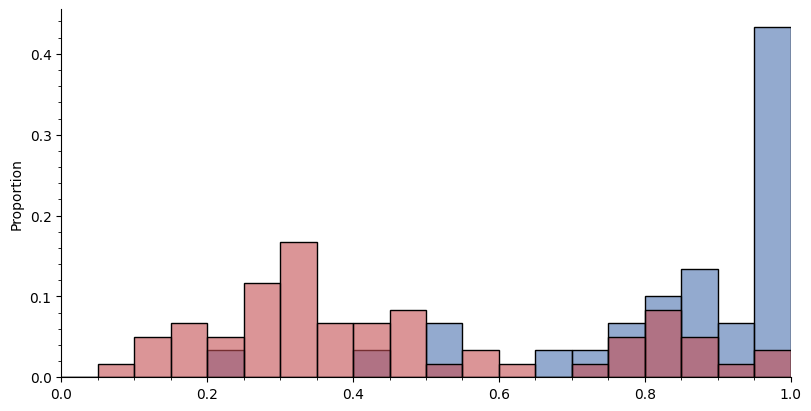

In [62]:
_, ax = plt.subplots(figsize=(8, 4))
sns.histplot(
    extero_sensitivity,
    color="#4c72b0",
    alpha=0.6,
    stat="proportion",
    binwidth=0.05,
    binrange=(0, 1),
    ax=ax,
)
sns.histplot(
    intero_sensitivity,
    color="#c44e52",
    alpha=0.6,
    stat="proportion",
    binwidth=0.05,
    binrange=(0, 1),
    ax=ax,
)

ax.set(xlim=(0, 1))
ax.minorticks_on()
sns.despine()